In [1]:
import re
import matplotlib.pyplot as plt
import os

def analyze_and_plot_training_log(file_path):
    """
    Reads a training log file, extracts the epoch and 100% completion lines,
    removes duplicates (keeping the last entry for each epoch), extracts
    epoch number and train_loss, and plots the results.
    """
    
    print(f"--- Starting analysis of {file_path} ---")

    # Regex to capture the Epoch number (Group 1) and the train_loss value (Group 2).
    # It specifically looks for lines containing "Epoch:", "100%", and "train_loss=".
    # The pattern handles potential variations in spacing and the colored ANSI codes.
    # Note: \s* allows for zero or more whitespace characters.
    log_pattern = re.compile(r'Epoch:\s*(\d+):\s*100%[^\n]*train_loss=([\d\.]+)')
    
    # Use a dictionary to store the data: {epoch_number: train_loss}
    # This automatically handles the requirement to keep only one entry per epoch,
    # as subsequent identical epoch keys will overwrite the previous value.
    extracted_data = {}
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line_number, line in enumerate(f, 1):
                # Search for the pattern in the current line
                match = log_pattern.search(line)
                
                if match:
                    try:
                        # Group 1 is the epoch number (e.g., '2')
                        epoch = int(match.group(1))
                        # Group 2 is the loss value (e.g., '145' or '123.45')
                        loss = float(match.group(2))
                        
                        # Store or overwrite the data point
                        extracted_data[epoch] = loss
                        # print(f"Found and stored: Epoch {epoch}, Loss {loss}") # Uncomment for verbose debugging
                        
                    except ValueError as e:
                        print(f"Warning: Could not convert data on line {line_number}. Error: {e}")
                        
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return
    except Exception as e:
        print(f"An unexpected error occurred while reading the file: {e}")
        return

    if not extracted_data:
        print("No valid 'Epoch: X: 100%' lines with 'train_loss' found in the file.")
        return

    # 1. Sort the extracted data by epoch number
    # .items() returns (key, value) tuples which are (epoch, loss)
    sorted_epochs_losses = sorted(extracted_data.items(), key=lambda item: item[0])
    
    epochs = [item[0] for item in sorted_epochs_losses]
    losses = [item[1] for item in sorted_epochs_losses]
    
    print(f"\nSuccessfully extracted {len(epochs)} unique data points (Epochs: {epochs[0]} to {epochs[-1]}).")
    
    # 2. Plotting the results
    plt.figure(figsize=(10, 6))
    
    # Line plot with markers
    plt.plot(epochs, losses, color='#1f77b4', linewidth=2)
    
    # Titles and Labels
    plt.title('Training Loss Over Epochs', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch Number', fontsize=14)
    plt.ylabel('Training Loss', fontsize=14)
    
    # Grid for better readability
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Set x-ticks to be only the epoch numbers found
    # plt.xticks(epochs)
    
    # Add annotation for the last point
    last_epoch = epochs[-1]
    last_loss = losses[-1]
    print(f"Final Loss: {last_loss:.2f}")
    # plt.annotate(f'Final Loss: {last_loss:.2f}', 
    #              (last_epoch, last_loss), 
    #              textcoords="offset points", 
    #              xytext=(-15, 15), 
    #              ha='right', 
    #              arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color='black'))

    # Display the plot
    plt.tight_layout()
    plt.show()
    print("\n--- Plotting complete ---")




--- Starting analysis of ddpm_train_3377(time).out ---

Successfully extracted 300 unique data points (Epochs: 1 to 300).
Final Loss: 88.30


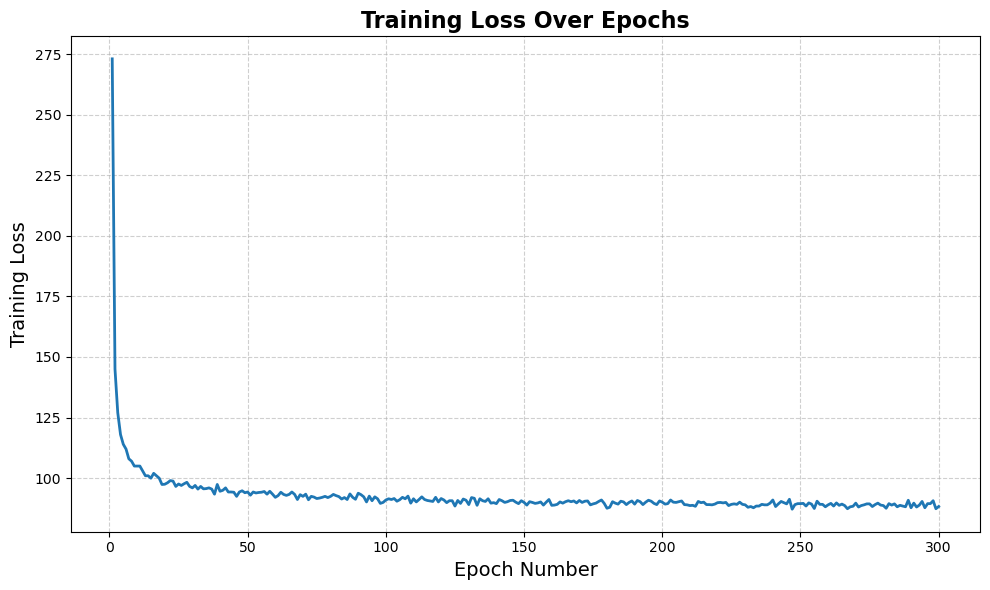


--- Plotting complete ---


In [2]:

# Define the path to the sample file.
INPUT_FILE = "ddpm_train_3377(time).out"

# Create the dummy file if it doesn't exist (for easy running)
if not os.path.exists(INPUT_FILE):
    print(f"The sample file '{INPUT_FILE}' was not found. Please ensure it exists with the content in 'training.out'.")
    # Exit if the file does not exist to avoid immediate error
    # In this interactive environment, we assume the user will save the second file.
    # However, for robustness, we can exit gracefully.
    # Note: Since I am generating the file next, this check will fail on the first run 
    # but the file will be available when the user tries to run the script.
    pass 
    
analyze_and_plot_training_log(INPUT_FILE)

--- Starting analysis of ddpm_train_3755_(input).out ---

Successfully extracted 300 unique data points (Epochs: 1 to 300).
Final Loss: 89.80


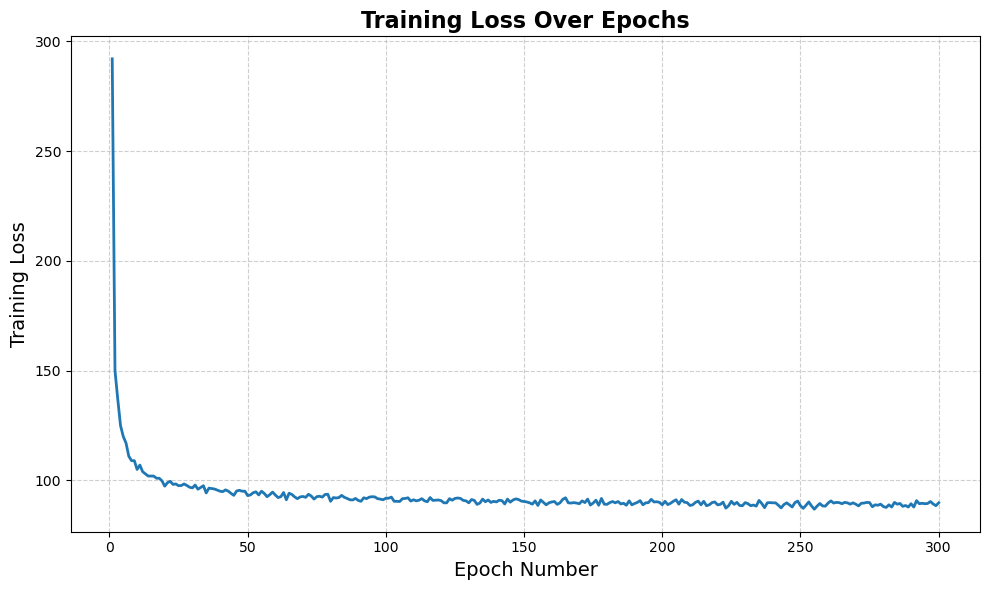


--- Plotting complete ---


In [3]:
# Define the path to the sample file.
INPUT_FILE = "ddpm_train_3755_(input).out"

# Create the dummy file if it doesn't exist (for easy running)
if not os.path.exists(INPUT_FILE):
    print(f"The sample file '{INPUT_FILE}' was not found. Please ensure it exists with the content in 'training.out'.")
    # Exit if the file does not exist to avoid immediate error
    # In this interactive environment, we assume the user will save the second file.
    # However, for robustness, we can exit gracefully.
    # Note: Since I am generating the file next, this check will fail on the first run 
    # but the file will be available when the user tries to run the script.
    pass 
    
analyze_and_plot_training_log(INPUT_FILE)

--- Starting analysis of ddpm_train_cfg_6292.out ---

Successfully extracted 300 unique data points (Epochs: 1 to 300).
Final Loss: 88.80


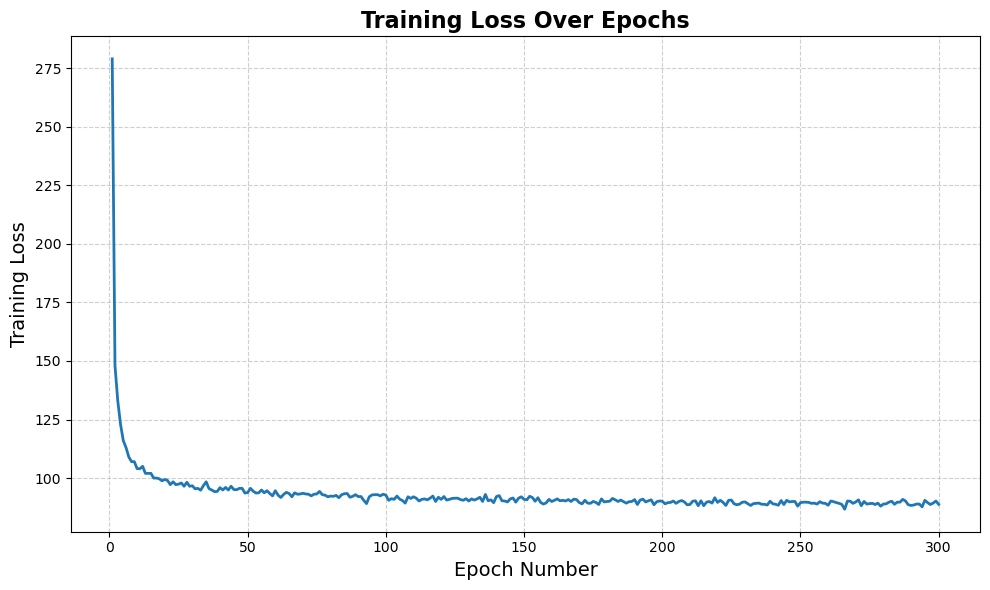


--- Plotting complete ---


In [4]:

# Define the path to the sample file.
INPUT_FILE = "ddpm_train_cfg_6292.out"

# Create the dummy file if it doesn't exist (for easy running)
if not os.path.exists(INPUT_FILE):
    print(f"The sample file '{INPUT_FILE}' was not found. Please ensure it exists with the content in 'training.out'.")
    # Exit if the file does not exist to avoid immediate error
    # In this interactive environment, we assume the user will save the second file.
    # However, for robustness, we can exit gracefully.
    # Note: Since I am generating the file next, this check will fail on the first run 
    # but the file will be available when the user tries to run the script.
    pass 
    
analyze_and_plot_training_log(INPUT_FILE)